In [6]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2026-04-05 12:27:30.645081: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-05 12:27:30.700284: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-05 12:27:34.033571: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [8]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from PMAPUtil import *
from sklearn.decomposition import PCA

In [9]:
columns = [
    # Demographics
    "gender",
    "age",

    # Neurologic
    "first_mGCS",
    "flo_first_r_cpn_glasgow_coma_scale_score",

    # Vital Signs – First
    "flo_first_bp_systolic",
    "flo_first_bp_diastolic",
    "flo_first_r_map",
    "flo_first_temperature",
    "flo_first_r_ed_pre-arrival_pulse_(heart_rate)",
    "flo_first_r_fio2",
    "flo_first_r_spo2:fio2_covid-19_calculation",

    # Severity Scores
    "flo_first_r_sofa_score",

    "flo_first_r_jhm_ip_sofa_cv_score",
    "flo_first_r_jhm_ip_sofa_cns_score",
    "flo_first_r_jhm_ip_sofa_coagulation_score",
    "flo_first_r_jhm_ip_sofa_liver_score",
    "flo_first_r_jhm_ip_sofa_renal_score",
    
    # Respiratory / Oxygenation
    "flo_first_r_jhm_ip_pao2/fio2",
    "flo_first_r_jhm_ip_rt_vent_fio2_(%)",
    "flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate",
    "flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate",

    # Hemodynamics / Shock
    "flo_first_r_norepinephrine_volume",

    # Renal / Urine Output
    "flo_first_jhm_ip_4hr_urine_output_goal_(12ml/kg)_is_at_least",
    "flo_first_jhm_ip_4hr_urine_output_goal_(2ml/kg)_is_at_least",

    # Anthropometrics
    "flo_first_r_bmi",

    # Labs – First
    "lab_first_troponin",
    "lab_first_creatinine,whole_blood",
    "lab_first_lactate",
    "lab_first_glucose,whole_blood",
    "lab_first_potassium,whole_blood",
    "lab_first_sodium,whole_blood",
    "lab_first_hemoglobin,total,whole_blood",
    "lab_first_aptt",

    'hypothermia',
    'asystole',
     'pea',
     'cardiopulmonary arrest w/ resuscitation',
     'VF',
]


In [10]:
import re
import pandas as pd
from difflib import SequenceMatcher

# ---------------------------------------------------
# 1) all pasted columns as targets
# ---------------------------------------------------
target_columns = [
    'SUBJID',
    'groupe',
    'CPC_SC3',
    'J0_SEX',
    'J0_TAILLE',
    'J0_POIDS',
    'J0_BMI',
    'J0_AGE',
    'J0_PAS',
    'J0_PAD',
    'J0_PAM',
    'J0_FC',
    'J0_SPO2',
    'J0_GLASGOW',
    'J0_GLASGOW_CONTROLE',
    'J0_OCULAIRE',
    'J0_VERBALE',
    'J0_MOTRICE',
    'J0_PUPILG',
    'J0_PUPILG_REA',
    'J0_PUPILD',
    'J0_PUPILD_REA',
    'J0_CILIAIRE',
    'J0_CORNEEN',
    'J0_REFLEXVEST',
    'J0_REFLEXCEPH',
    'J0_REFLEXCARD',
    'J0_TEMP',
    'J0_IGSII',
    'J0_MCCABE',
    'J0_KNAUS',
    'J0_CHARLSON1',
    'J0_CHARLSON2',
    'J0_CHARLSON3',
    'J0_CHARLSON4',
    'J0_CHARLSON5',
    'J0_CHARLSON6',
    'J0_CHARLSON7',
    'J0_CHARLSON8',
    'J0_CHARLSON9',
    'J0_CHARLSON10',
    'J0_CHARLSON11',
    'J0_CHARLSON12',
    'J0_CHARLSON13',
    'J0_CHARLSON14',
    'V0_CHARLSON15',
    'V0_CHARLSON16',
    'V0_CHARLSON17',
    'V0_CHARLSON18',
    'V0_CHARLSON18B',
    'V0_CHARLSON19',
    'J0_CHARLSON',
    'J0_ATCD',
    'J0_CARDIO',
    'J0_NYHA',
    'J0_MYOCARD',
    'J0_ARTERIO',
    'J0_HTA',
    'J0_POUMON',
    'J0_IRC',
    'J0_HYPERCAP',
    'J0_O2',
    'J0_TABAC',
    'J0_RYTHM',
    'J0_CAUSE2_ACR',
    'J0_DSA',
    'J0_DSA_P',
    'J0_TEMOIN',
    'J0_TEMOIN_MASSE',
    'J0_LIEU_ACR',
    'J0_NOFLOW',
    'J0_LOWFLOW',
    'J0_ADRE',
    'J0_ADRE_DOS',
    'J0_CORDA',
    'J0_CORDA_DOS',
    'J0_BICARB',
    'J0_BICARB_DOS',
    'V0_REFROIDI',
    'V0_CHOC_AV',
    'V0_CHOC_AP',
    'V0_PLANCHE',
    'V0_THROMBO',
    'V0_CORO_ACR',
    'V0_ANGIO_ACR',
    'V0_ANGIO_YES',
    'V0_BALLON',
    'V0_ACR2',
    'J0_CURAR',
    'J0_SEDATIF',
    'J0_MORPHIN',
    'J0_COAGUL',
    'J0_AGREG',
    'J0_ANTIBIO',
    'J0_AMINE',
    'J0_NORA',
    'J0_ADRE2',
    'J0_DOBU',
    'J0_DOPA',
    'J0_PEP',
    'J0_FIO2',
    'J0_VT',
    'J0_FR',
    'BIO_LEUCO',
    'BIO_HEMO',
    'BIO_PLAQ',
    'BIO_TP',
    'BIO_DDIMERE',
    'BIO_SODIUM',
    'BIO_POTAS',
    'BIO_UREE',
    'BIO_CREAT',
    'BIO_CALCIUM',
    'BIO_MAGNE',
    'BIO_GLYCEMI',
    'BIO_PROTID',
    'BIO_LIPAS',
    'BIO_TROPO',
    'BIO_TEMP',
    'BIO_FIO2',
    'BIO_PH',
    'BIO_PAO2',
    'BIO_PACO2',
    'BIO_BICARB',
    'BIO_LACTAT',
    'BIO_TROPO2',
    'BIO_TROPO_CGT',
    'ECG',
    'ECG_QTC',
    'ECG_ANOMALI',
    'ECG_SUS_ST',
    'ECG_SOUS_ST',
    'ECG_BAVI',
    'ECG_BAVII',
    'ECG_BAVIII',
    'ECG_BBG',
    'ECG_BBD',
    'ECG_TACHICARD',
    'ECG_FIBRIL',
    'ECG_SALV_VENT',
    'ECG_FLUTER',
    'ECG_SALV_SUPRA',
    'SOFA_SC',
    'SOFA_RESPIR',
    'SOFA_CARDIO',
    'SOFA_COAG',
    'SOFA_NEURO',
    'SOFA_FOIE',
    'SOFA_RENAL',
    'EI_EI',
    'EI_HEMOSEVER',
    'EI_TRANSFUS',
    'EI_INTRACER',
    'EI_CHIR',
    'EI_EXTRARENAL',
    'EI_OAP',
    'EI_ECHO',
    'EI_DIURETIQ',
    'EI_CONVULS',
    'EI_ARYTHMI',
    'EI_ANTIEPILEPTIQ',
    'BARTHEL_SC',
    'SOFA_SC7',
    'SOFA_SC1',
    'DS_DC',
    'DAYS_ALIVE_30',
    'CPC12',
    'SEX'
]

# ---------------------------------------------------
# 2) normalize names for better matching
# ---------------------------------------------------
def normalize_col(s: str) -> str:
    s = str(s).lower().replace('_', ' ')

    replacements = {
        'subjid': 'subject patient id',
        'groupe': 'group treatment arm',
        'taille': 'height',
        'poids': 'weight',
        'bmi': 'body mass index',
        'age': 'age',
        'pas': 'systolic blood pressure sbp',
        'pad': 'diastolic blood pressure dbp',
        'pam': 'mean arterial pressure map',
        'fc': 'heart rate pulse',
        'spo2': 'oxygen saturation spo2',
        'glasgow': 'glasgow coma scale gcs',
        'oculaire': 'eye ocular',
        'verbale': 'verbal',
        'motrice': 'motor',
        'pupilg': 'left pupil',
        'pupild': 'right pupil',
        'rea': 'reactive reactivity',
        'ciliaire': 'ciliary reflex',
        'corneen': 'corneal reflex',
        'reflexvest': 'vestibular reflex',
        'reflexceph': 'cephalic reflex',
        'reflexcard': 'cardiac reflex',
        'igsii': 'saps ii severity score',
        'mccabe': 'mccabe score',
        'knaus': 'knaus apache chronic health',
        'atcd': 'past medical history comorbidity',
        'cardio': 'cardiovascular history',
        'nyha': 'nyha heart failure class',
        'myocard': 'myocardial infarction',
        'arterio': 'peripheral arterial disease vascular disease',
        'hta': 'hypertension',
        'poumon': 'lung pulmonary disease',
        'irc': 'chronic kidney disease renal insufficiency',
        'hypercap': 'hypercapnia',
        'o2': 'oxygen therapy oxygen',
        'tabac': 'smoking tobacco',
        'rythm': 'rhythm arrest rhythm',
        'cause2 acr': 'cardiac arrest cause',
        'dsa': 'defibrillation shock',
        'temoin': 'witnessed witnessed arrest',
        'lieu acr': 'cardiac arrest location',
        'noflow': 'no flow',
        'lowflow': 'low flow',
        'adre': 'epinephrine adrenaline',
        'corda': 'cordarone amiodarone',
        'bicarb': 'bicarbonate',
        'refroidi': 'cooling hypothermia targeted temperature management ttm',
        'choc': 'shock',
        'planch': 'board',
        'thrombo': 'thrombolysis thrombosis',
        'coro acr': 'coronary angiography arrest',
        'angio': 'angiography',
        'ballon': 'balloon pump',
        'curar': 'neuromuscular blocker paralysis',
        'sedatif': 'sedation sedative',
        'morphin': 'morphine opioid',
        'coagul': 'anticoagulation coagulopathy',
        'agreg': 'antiplatelet aggregation',
        'antibio': 'antibiotic',
        'amine': 'vasopressor amine',
        'nora': 'norepinephrine noradrenaline',
        'dobu': 'dobutamine',
        'dopa': 'dopamine',
        'pep': 'peep positive end expiratory pressure',
        'fio2': 'fraction inspired oxygen fio2',
        'vt': 'tidal volume vt ventricular tachycardia',
        'fr': 'respiratory rate',
        'leuco': 'white blood cell wbc leukocyte',
        'hemo': 'hemoglobin hgb',
        'plaq': 'platelets platelet count',
        'tp': 'prothrombin time pt',
        'ddimere': 'd dimer',
        'uree': 'urea bun blood urea nitrogen',
        'creat': 'creatinine',
        'magne': 'magnesium',
        'glycemi': 'glucose glycemia',
        'protid': 'protein total protein',
        'lipas': 'lipase',
        'tropo': 'troponin',
        'ph': 'ph',
        'pao2': 'arterial oxygen pao2',
        'paco2': 'arterial carbon dioxide paco2',
        'lactat': 'lactate',
        'qtc': 'qt corrected qtc',
        'anomali': 'abnormality',
        'sus st': 'st elevation',
        'sous st': 'st depression',
        'bavi': 'av block first degree',
        'bavii': 'av block second degree',
        'baviii': 'av block third degree',
        'bbg': 'left bundle branch block',
        'bbd': 'right bundle branch block',
        'tachicard': 'tachycardia',
        'fibril': 'fibrillation',
        'salv vent': 'ventricular tachycardia ventricular run',
        'fluter': 'flutter',
        'salv supra': 'supraventricular run',
        'respir': 'respiratory',
        'cardio': 'cardiovascular cardiac',
        'coag': 'coagulation',
        'neuro': 'neurologic neurological',
        'foie': 'liver hepatic',
        'renal': 'renal kidney',
        'hemosever': 'severe bleeding hemorrhage',
        'transfus': 'transfusion',
        'intracer': 'intracerebral intracranial',
        'chir': 'surgery surgical',
        'oap': 'pulmonary edema',
        'echo': 'echocardiography echo',
        'diuretiq': 'diuretic',
        'convuls': 'seizure convulsion',
        'arythmi': 'arrhythmia',
        'antiepileptiq': 'antiepileptic',
        'barthel': 'barthel functional status',
        'dc': 'death deceased',
        'days alive 30': 'days alive at 30 days',
        'cpc': 'cerebral performance category'
    }

    for old, new in replacements.items():
        s = s.replace(old, new)

    s = re.sub(r'[^a-z0-9]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def similarity(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()

# ---------------------------------------------------
# 3) score each target against all columns in df_other
# ---------------------------------------------------
def score_target_against_columns(target_col, candidate_columns, top_n=2):
    norm_target = normalize_col(target_col)
    target_tokens = set(norm_target.split())

    rows = []
    for col in candidate_columns:
        norm_col = normalize_col(col)
        col_tokens = set(norm_col.split())

        score = similarity(norm_target, norm_col)

        if norm_target == norm_col:
            score += 1.0
        elif norm_target in norm_col or norm_col in norm_target:
            score += 0.35

        if len(target_tokens) > 0:
            overlap = len(target_tokens & col_tokens) / len(target_tokens)
            score += 0.5 * overlap

        rows.append({
            'target_column': target_col,
            'candidate_column': col,
            'score': score
        })

    return pd.DataFrame(rows).sort_values('score', ascending=False).head(top_n)

def search_all_target_columns(df_other, target_columns=target_columns, top_n=2):
    results = []
    for target in target_columns:
        results.append(score_target_against_columns(target, df_other.columns, top_n=top_n))
    return pd.concat(results, ignore_index=True)

# ---------------------------------------------------
# 4) run it
# ---------------------------------------------------
# replace df_other with your other dataset
columns2 = [x for x in myPredictorsDf.columns if '_min_' not in x.lower() and '_max_' not in x.lower() and '_last_' not in x.lower() and '_mean_' not in x.lower()]
top2_matches = search_all_target_columns(myPredictorsDf[columns2], target_columns=target_columns, top_n=2)

# tidy output
top2_matches = top2_matches.sort_values(['target_column', 'score'], ascending=[True, False]).reset_index(drop=True)
top2_matches

NameError: name 'myPredictorsDf' is not defined

In [ ]:
columns

['gender',
 'age',
 'first_mGCS',
 'flo_first_r_cpn_glasgow_coma_scale_score',
 'flo_first_bp_systolic',
 'flo_first_bp_diastolic',
 'flo_first_r_map',
 'flo_first_temperature',
 'flo_first_r_ed_pre-arrival_pulse_(heart_rate)',
 'flo_first_r_fio2',
 'flo_first_r_spo2:fio2_covid-19_calculation',
 'flo_first_r_sofa_score',
 'flo_first_r_jhm_ip_sofa_cv_score',
 'flo_first_r_jhm_ip_sofa_cns_score',
 'flo_first_r_jhm_ip_sofa_coagulation_score',
 'flo_first_r_jhm_ip_sofa_liver_score',
 'flo_first_r_jhm_ip_sofa_renal_score',
 'flo_first_r_jhm_ip_pao2/fio2',
 'flo_first_r_jhm_ip_rt_vent_fio2_(%)',
 'flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate',
 'flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate',
 'flo_first_r_norepinephrine_volume',
 'flo_first_jhm_ip_4hr_urine_output_goal_(12ml/kg)_is_at_least',
 'flo_first_jhm_ip_4hr_urine_output_goal_(2ml/kg)_is_at_least',
 'flo_first_r_bmi',
 'lab_first_troponin',
 'lab_first_creatinine,whole_blood',
 'lab_first_lactate',
 'lab_first_glu

In [ ]:
columns = top2_matches.candidate_column.tolist()
columns += [
    'hypothermia',
    'asystole',
     'pea',
     'cardiopulmonary arrest w/ resuscitation',
     'VF',
]


In [ ]:
# [x for x in myPredictorsDf.columns if 'score' in x.lower() and 'first' in x.lower()]

In [ ]:
# myPredictorsDf.columns

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('PMAP_Predictors2.csv')

    # top_corr = pd.read_csv('top_correlations.csv')
    columns_to_drop = []#top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x.lower() or 'dx_' == x[0:3] ]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=columns_to_drop+  myColumns + ['first_mGCS', 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [12]:
myTreatmentColumn = 'hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aSkipTemp = False) 

In [13]:
columns_filter = np.unique([x for x in columns if x in X_test.columns])

X_train = X_train[columns_filter]
X_test = X_test[columns_filter]

In [14]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )

In [16]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    # myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    # myCovariates.set_output(transform="pandas")
    # myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    # myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [17]:
# X_train = X_train.loc[:, X_train.isnull().mean() < 0.9]
# X_test = X_test[X_train.columns]

In [18]:
# [x for x in X_train.columns if 'death' in x.lower()]

In [19]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [20]:
X_test_transf.columns

Index(['num__age', 'num__flo_first_bp_diastolic', 'num__flo_first_bp_systolic',
       'num__flo_first_jhm_ip_4hr_urine_output_goal_(12ml/kg)_is_at_least',
       'num__flo_first_jhm_ip_4hr_urine_output_goal_(2ml/kg)_is_at_least',
       'num__flo_first_r_bmi', 'num__flo_first_r_cpn_glasgow_coma_scale_score',
       'num__flo_first_r_ed_pre-arrival_pulse_(heart_rate)',
       'num__flo_first_r_fio2', 'num__flo_first_r_jhm_ip_pao2/fio2',
       'num__flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate',
       'num__flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate',
       'num__flo_first_r_jhm_ip_rt_vent_fio2_(%)', 'num__flo_first_r_map',
       'num__flo_first_r_norepinephrine_volume', 'num__flo_first_r_sofa_score',
       'num__flo_first_r_spo2:fio2_covid-19_calculation',
       'num__flo_first_temperature', 'num__lab_first_aptt',
       'num__lab_first_creatinine,whole_blood',
       'num__lab_first_glucose,whole_blood',
       'num__lab_first_hemoglobin,total,whole_blood'

In [21]:
import torch
import torch.nn as nn

class MLPBinary(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)  # logits (no sigmoid here)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # (batch,)


    @torch.no_grad()
    def predict_proba(self, X, device=None, batch_size=8192):
        """
        sklearn-style: returns shape (n, 2) = [P(class0), P(class1)]
        """
        self.eval()
        device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.to(device)

        # X can be numpy or pandas
        if hasattr(X, "to_numpy"):
            X = X.to_numpy()
        X = np.asarray(X, dtype=np.float32)

        probs1 = []
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(device)
            logits = self(xb)
            p1 = torch.sigmoid(logits).detach().cpu().numpy()
            probs1.append(p1)

        p1 = np.concatenate(probs1, axis=0).reshape(-1)
        p0 = 1.0 - p1
        return np.stack([p0, p1], axis=1)

    @torch.no_grad()
    def predict(self, X, threshold=0.5, **kwargs):
        """
        sklearn-style: returns class labels (0/1)
        """
        proba = self.predict_proba(X, **kwargs)[:, 1]
        return (proba >= threshold).astype(int)


In [22]:
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score

def to_tensor(x):
    # works if x is numpy array or pandas dataframe
    if hasattr(x, "to_numpy"):
        x = x.to_numpy()
    return torch.tensor(x, dtype=torch.float32)

def train_mlp(
    X_train, y_train,
    X_val, y_val,
    epochs=15,
    batch_size=32,
    lr=1e-3,
    weight_decay=0.0,
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # Ensure y is shape (N,) float32 in {0,1}
    y_train_np = y_train.to_numpy().reshape(-1) if hasattr(y_train, "to_numpy") else np.asarray(y_train).reshape(-1)
    y_val_np   = y_val.to_numpy().reshape(-1) if hasattr(y_val, "to_numpy") else np.asarray(y_val).reshape(-1)

    X_train_t = to_tensor(X_train)
    y_train_t = torch.tensor(y_train_np, dtype=torch.float32)
    X_val_t   = to_tensor(X_val)
    y_val_t   = torch.tensor(y_val_np, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, drop_last=False)

    model = MLPBinary(input_dim=X_train_t.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)                  # (batch,)
            loss = criterion(logits, yb)        # BCE with logits
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # ---- validate ----
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t.to(device)).detach().cpu().numpy()
            val_probs = 1 / (1 + np.exp(-val_logits))  # sigmoid
            val_pred = (val_probs >= 0.5).astype(int)

        val_auc = roc_auc_score(y_val_np, val_probs) if len(np.unique(y_val_np)) == 2 else np.nan
        val_acc = accuracy_score(y_val_np, val_pred)

        print(f"Epoch {epoch:02d}/{epochs} | loss={np.mean(train_losses):.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    return model


In [23]:
# If your y's are DataFrames with a single column, flatten them:
ytr = y_train.reset_index(drop=True)
yte = y_test.reset_index(drop=True)
if hasattr(ytr, "shape") and len(getattr(ytr, "shape", ())) == 2 and ytr.shape[1] == 1:
    ytr = ytr.iloc[:, 0]
if hasattr(yte, "shape") and len(getattr(yte, "shape", ())) == 2 and yte.shape[1] == 1:
    yte = yte.iloc[:, 0]

model_torch = train_mlp(
    X_train_transf, ytr,
    X_test_transf, yte,
    epochs=50,
    batch_size=32,
    lr=1e-4
)


Epoch 01/50 | loss=0.6754 | val_acc=0.7545 | val_auc=0.3732
Epoch 02/50 | loss=0.6685 | val_acc=0.7545 | val_auc=0.4260
Epoch 03/50 | loss=0.6604 | val_acc=0.7545 | val_auc=0.4661
Epoch 04/50 | loss=0.6484 | val_acc=0.7545 | val_auc=0.5220
Epoch 05/50 | loss=0.6362 | val_acc=0.7545 | val_auc=0.5747
Epoch 06/50 | loss=0.6167 | val_acc=0.7545 | val_auc=0.6148
Epoch 07/50 | loss=0.5919 | val_acc=0.7545 | val_auc=0.6495
Epoch 08/50 | loss=0.5713 | val_acc=0.7545 | val_auc=0.6708
Epoch 09/50 | loss=0.5490 | val_acc=0.7545 | val_auc=0.6877
Epoch 10/50 | loss=0.5438 | val_acc=0.7545 | val_auc=0.6989
Epoch 11/50 | loss=0.5340 | val_acc=0.7545 | val_auc=0.7075
Epoch 12/50 | loss=0.5278 | val_acc=0.7545 | val_auc=0.7134
Epoch 13/50 | loss=0.5311 | val_acc=0.7545 | val_auc=0.7220
Epoch 14/50 | loss=0.5160 | val_acc=0.7545 | val_auc=0.7293
Epoch 15/50 | loss=0.5182 | val_acc=0.7545 | val_auc=0.7337
Epoch 16/50 | loss=0.5118 | val_acc=0.7545 | val_auc=0.7376
Epoch 17/50 | loss=0.5084 | val_acc=0.75

In [24]:
from sklearn.metrics import roc_auc_score

def predict_proba(model, X, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    X_t = to_tensor(X).to(device)
    with torch.no_grad():
        logits = model(X_t).detach().cpu().numpy()
    return 1 / (1 + np.exp(-logits))

def bootstrap_auc_ci(y_true, y_score, n_bootstraps=2000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true).reshape(-1)
    y_score = np.asarray(y_score).reshape(-1)

    aucs = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    aucs = np.asarray(aucs)
    return roc_auc_score(y_true, y_score), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

probs_test = predict_proba(model_torch, X_test_transf)
auc, lo, hi = bootstrap_auc_ci(yte, probs_test)
print(f"Test AUC = {auc:.3f} (95% CI {lo:.3f}–{hi:.3f})")


Test AUC = 0.778 (95% CI 0.723–0.832)


In [25]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
def missingness_table(df, treatment_col, threshold=30.0, exclude_cols=None, use_fisher_if_small=True):
    """
    Create a missingness summary table for one dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Pre-imputation dataframe.
    treatment_col : str
        Name of binary treatment column (0/1).
    threshold : float
        Percent missing threshold to flag, default 30.
    exclude_cols : list or None
        Columns to exclude from the missingness table.
    use_fisher_if_small : bool
        Use Fisher's exact test when expected cell counts are small.

    Returns
    -------
    pd.DataFrame
    """
    if exclude_cols is None:
        exclude_cols = []

    cols = [c for c in df.columns if c not in exclude_cols and c != treatment_col]

    rows = []

    treat = df[treatment_col]

    for col in cols:
        miss = df[col].isna().astype(int)

        n_total = len(df)
        n_missing = miss.sum()
        pct_missing = 100 * n_missing / n_total

        miss_ttm = miss[treat == 1]
        miss_nottm = miss[treat == 0]

        n_ttm = (treat == 1).sum()
        n_nottm = (treat == 0).sum()

        pct_missing_ttm = 100 * miss_ttm.mean() if n_ttm > 0 else np.nan
        pct_missing_nottm = 100 * miss_nottm.mean() if n_nottm > 0 else np.nan

        # contingency table:
        # rows = treatment group
        # cols = missing / not missing
        table = np.array([
            [miss_nottm.sum(), (treat == 0).sum() - miss_nottm.sum()],
            [miss_ttm.sum(), (treat == 1).sum() - miss_ttm.sum()]
        ])

        # default p-value
        pval = np.nan
        test_used = None

        try:
            chi2, p_chi, dof, expected = chi2_contingency(table, correction=False)

            if use_fisher_if_small and (expected < 5).any():
                _, pval = fisher_exact(table)
                test_used = "Fisher"
            else:
                pval = p_chi
                test_used = "Chi-square"
        except Exception:
            pval = np.nan
            test_used = "Failed"

        rows.append({
            "variable": col,
            "n_missing": int(n_missing),
            "pct_missing": pct_missing,
            "pct_missing_no_ttm": pct_missing_nottm,
            "pct_missing_ttm": pct_missing_ttm,
            "abs_diff_pct": abs(pct_missing_ttm - pct_missing_nottm),
            "p_value": pval,
            "test": test_used,
            "flag_gt_30pct": pct_missing > threshold
        })

    out = pd.DataFrame(rows).sort_values(
        ["flag_gt_30pct", "pct_missing"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return out
miss_eicu = missingness_table(
    df=X_train,
    treatment_col="hypothermia",
    exclude_cols=["patient_id"]
)
def missingness_summary_stats(miss_df):
    return {
        "n_variables": len(miss_df),
        "n_gt_30pct": int(miss_df["flag_gt_30pct"].sum()),
        "max_pct_missing": miss_df["pct_missing"].max(),
        "median_pct_missing": miss_df["pct_missing"].median(),
        "n_p_lt_005": int((miss_df["p_value"] < 0.05).sum())
    }
print("eICU:", missingness_summary_stats(miss_eicu))

eICU: {'n_variables': 35, 'n_gt_30pct': 21, 'max_pct_missing': np.float64(85.14412416851441), 'median_pct_missing': np.float64(48.00443458980045), 'n_p_lt_005': 4}


In [26]:
miss_eicu = miss_eicu.rename(columns={
    "variable": "Variable",
    "n_missing": "Missing, n",
    "pct_missing": "Missing, %",
    "pct_missing_no_ttm": "Missing in No-TTM Group, %",
    "pct_missing_ttm": "Missing in TTM Group, %",
    "abs_diff_pct": "Absolute Difference, %",
    "p_value": "P Value",
    "test": "Statistical Test"
}).drop(columns=["flag_gt_30pct"])

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'PMAP NN Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

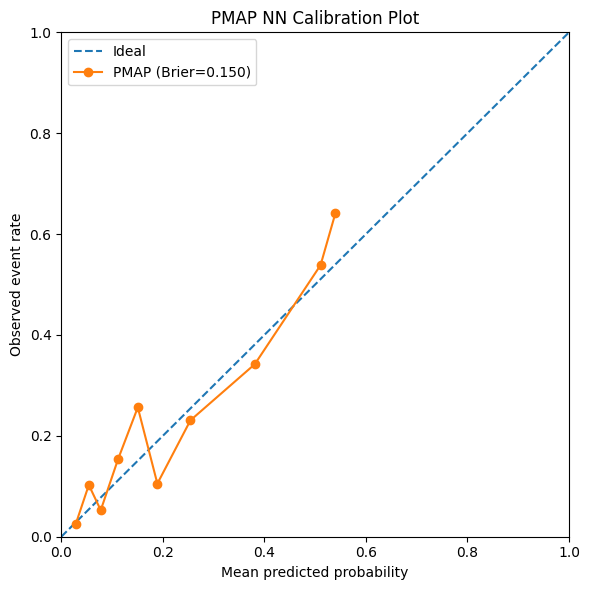

In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    """
    Compute calibration intercept and slope by regressing outcome on logit(predicted probability).
    Ideal intercept = 0, slope = 1.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)

    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]

    return intercept, slope

def calibration_metrics(y_true, y_prob):
    """
    Return a small dict of discrimination + calibration metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    intercept, slope = calibration_intercept_slope(y_true, y_prob)

    return {
        "n": len(y_true),
        "event_rate": float(np.mean(y_true)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "calibration_intercept": float(intercept),
        "calibration_slope": float(slope),
    }

def plot_calibration_curve_one(y_true, y_prob, title="", n_bins=10, ax=None):
    """
    Reliability diagram / calibration curve.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax
def plot_calibration_curve_multi(model_preds, y_true, title="", n_bins=10):
    """
    model_preds: dict like {"XGBoost": probs1, "NN": probs2, "BART": probs3}
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")

    for model_name, y_prob in model_preds.items():
        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="quantile"
        )
        brier = brier_score_loss(y_true, y_prob)
        ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    return fig, ax

def build_calibration_table(results_dict):
    """
    results_dict structure:
    {
        ("eICU", "Neuro", "XGBoost"): (y_true, y_prob),
        ("eICU", "Neuro", "NN"): (y_true, y_prob),
        ...
    }
    """
    rows = []

    for (dataset, outcome, model), (y_true, y_prob) in results_dict.items():
        m = calibration_metrics(y_true, y_prob)
        m.update({
            "dataset": dataset,
            "outcome": outcome,
            "model": model
        })
        rows.append(m)

    df = pd.DataFrame(rows)
    df = df[
        [
            "dataset", "outcome", "model", "n", "event_rate",
            "auc", "brier", "calibration_intercept", "calibration_slope"
        ]
    ].sort_values(["dataset", "outcome", "model"]).reset_index(drop=True)

    return df
# y_pred_prob = model.predict(X_test)[:, 1]

results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, probs_test),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"PMAP":probs_test}, y_test, "PMAP NN Calibration Plot")

In [28]:
calib_table

,dataset,outcome,model,n,event_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,Mortality,NN,387,0.245478,0.77783,0.149878,0.098179,0.992777


In [95]:
miss_eicu.to_csv('table.csv')

In [81]:
miss_eicu[miss_eicu['pct_missing']  == 100]

,variable,n_missing,pct_missing,pct_missing_no_ttm,pct_missing_ttm,abs_diff_pct,p_value,test,flag_gt_30pct
0,flo_first_r_amb_fcc_assess,902,100.0,100.0,100.0,0.0,NaN,Failed,True
1,flo_first_r_amb_fcc_total_time,902,100.0,100.0,100.0,0.0,NaN,Failed,True
2,flo_first_r_jhm_ad_masa_score,902,100.0,100.0,100.0,0.0,NaN,Failed,True
3,flo_first_r_jhm_ip_impella_motor_current_mean,902,100.0,100.0,100.0,0.0,NaN,Failed,True
4,flo_first_r_pca_patient_dose_mg,902,100.0,100.0,100.0,0.0,NaN,Failed,True
5,flo_first_r_rt_vt_vent_spontaneous,902,100.0,100.0,100.0,0.0,NaN,Failed,True
6,"lab_first_blood_gases,pump_gas",902,100.0,100.0,100.0,0.0,NaN,Failed,True
7,"lab_first_glucose,_pleural_fluid",902,100.0,100.0,100.0,0.0,NaN,Failed,True
8,lab_first_hematocrit,902,100.0,100.0,100.0,0.0,NaN,Failed,True
9,lab_first_hemoglobin,902,100.0,100.0,100.0,0.0,NaN,Failed,True


In [82]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


In [24]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=10, batch_size=8, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5995 - loss: 0.7398 - roc_auc: 0.5092 - val_accuracy: 0.7526 - val_loss: 0.5731 - val_roc_auc: 0.6035
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7088 - loss: 0.5840 - roc_auc: 0.6002 - val_accuracy: 0.7577 - val_loss: 0.5489 - val_roc_auc: 0.6408
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7241 - loss: 0.5465 - roc_auc: 0.6446 - val_accuracy: 0.7603 - val_loss: 0.5316 - val_roc_auc: 0.6948
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7560 - loss: 0.5062 - roc_auc: 0.6949 - val_accuracy: 0.7603 - val_loss: 0.5150 - val_roc_auc: 0.7216
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7748 - loss: 0.4501 - roc_auc: 0.7848 - val_accuracy: 0.7603 - val_loss: 0.4959 - val_roc_auc: 0.7590
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7799 - loss: 0.4403 - roc_auc: 0.8023 - val_accuracy: 0.7655 - val_loss: 0.4896 - val_roc_auc:

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:05<00:00,  1.72it/s]


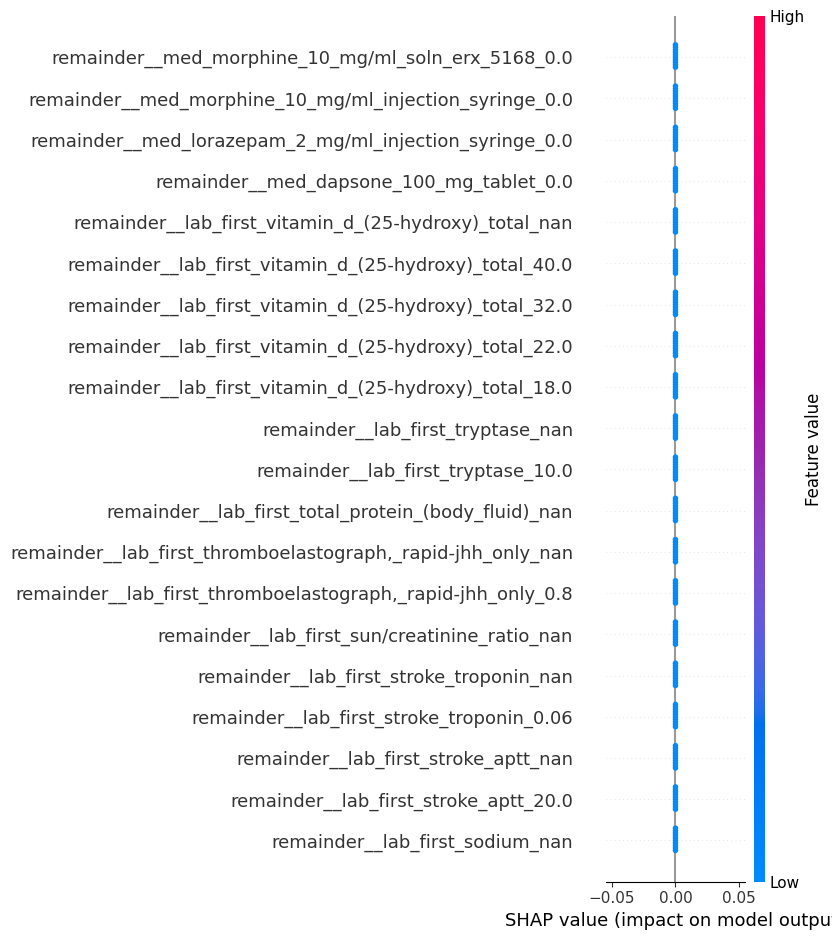

In [111]:
import shap
import numpy as np

# Use a small representative background set
X_background = X_test_transf[:100]
X_explain = X_test_transf[:10]

# shap needs a prediction function that outputs a 2D array
explainer = shap.KernelExplainer(model_torch.predict, X_background)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain)


In [112]:
# (importance_df['feature'] == feature_name).sum()

In [113]:
import numpy as np
import pandas as pd

# 1. Compute mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)  # shape: (n_features,)

# 2. Create a DataFrame for easy lookup and sorting
importance_df = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# 3. Find the rank of a specific feature
feature_name = "bin__hypothermia"  # replace with your actual feature
rank = importance_df.index[importance_df['feature'] == feature_name].item() + 1
score = importance_df.loc[importance_df['feature'] == feature_name, 'mean_abs_shap'].item()

print(f"🔍 Feature '{feature_name}' is ranked #{rank} out of {X_explain.shape[1]} in importance with mean(|SHAP|) = {score:.4f}")


🔍 Feature 'bin__hypothermia' is ranked #106 out of 310 in importance with mean(|SHAP|) = 0.0000


In [87]:
shap.plots.bar(shap_values)


TypeError: The shap_values argument must be an Explanation object, Cohorts object, or dictionary of Explanation objects!

In [88]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

In [89]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
ROC AUC Score: 0.3931


In [34]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_pred_proba, n_bootstraps=1000, ci=95, random_seed=42):
    rng = np.random.RandomState(random_seed)
    n = len(y_true)
    bootstrapped_scores = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[indices])) < 2:
            # We need at least one positive and one negative sample
            continue
        score = roc_auc_score(y_true[indices], y_pred_proba[indices])
        bootstrapped_scores.append(score)
    
    sorted_scores = np.sort(bootstrapped_scores)
    lower_bound = np.percentile(sorted_scores, (100 - ci) / 2)
    upper_bound = np.percentile(sorted_scores, 100 - (100 - ci) / 2)
    
    return lower_bound, upper_bound, sorted_scores

# Example usage
# y_true = np.array([...])
# y_pred_proba = np.array([...])

ci_lower, ci_upper, auc_scores = bootstrap_auc_ci(y_test.to_numpy(), y_pred_probs)
print(f"95% CI for AUC: [{ci_lower:.3f}, {ci_upper:.3f}]")


NameError: name 'y_pred_probs' is not defined

In [128]:
myX = pd.concat([X_train_transf.reset_index().drop(columns='index'), X_test_transf.reset_index().drop(columns='index')])
myY = pd.concat([y_train.reset_index().drop(columns='index'), y_test.reset_index().drop(columns='index')])

         Current function value: 5.707979
         Iterations: 35
         Current function value: 7.117202
         Iterations: 35
Likelihood ratio of test results:
Chi square statistic: -3979.6473563446016
p-value: 1.0
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                 1412
Model:                          Logit   Df Residuals:                     1409
Method:                           MLE   Df Model:                            2
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                  -7.905
Time:                        14:55:54   Log-Likelihood:                -8059.7
converged:                      False   LL-Null:                       -905.09
Covariance Type:            nonrobust   LLR p-value:                     1.000
                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

/home/mbranda1/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mbranda1/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


np.float64(1.0)

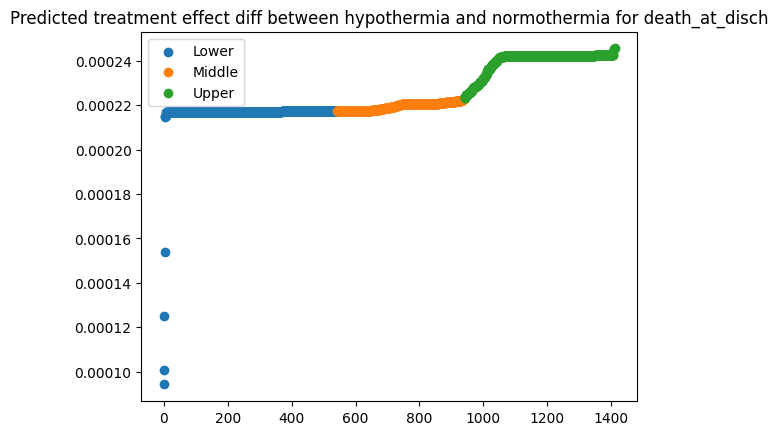

In [132]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = model_torch, \
                       aCategory = 'death_at_disch', aGroup = 'bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)

In [129]:
getTreatmentEffectDiff(aX = X_train_transf.reset_index().drop(columns='index'), aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'death_at_disch', aGroup = 'bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)

2026-04-03 14:55:27.112186: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Matrix size-incompatible: In[0]: [32,325], In[1]: [333,16]
	 [[{{node sequential_1_1/dense_3_1/Relu}}]]


InvalidArgumentError: Graph execution error:

Detected at node sequential_1_1/dense_3_1/Relu defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/mbranda1/.local/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/mbranda1/.local/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/mbranda1/.local/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/mbranda1/.local/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/cm/local/apps/python311/lib/python3.11/asyncio/base_events.py", line 607, in run_forever

  File "/cm/local/apps/python311/lib/python3.11/asyncio/base_events.py", line 1922, in _run_once

  File "/cm/local/apps/python311/lib/python3.11/asyncio/events.py", line 80, in _run

  File "/home/mbranda1/.local/lib/pytho